In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
import numpy as np
df["Sex"]=np.where(df["Sex"]=="male",1,0)

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
x=df[['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare']]
y=df["Survived"]
print(x.shape)
print(y.shape)

(891, 6)
(891,)


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [11]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(criterion="entropy",n_estimators=100,random_state=1)
model=rf.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [12]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
print()
print("Accuracy Score : ",accuracy_score(y_test,y_pred))

[[96 10]
 [28 45]]

Accuracy Score :  0.7877094972067039


In [13]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

96 10 28 45


In [14]:
# Accuracy Score
print("Accuracy Score : ",((TN+TP)/(TP+TN+FN+FP)))

Accuracy Score :  0.7877094972067039


In [15]:
# Error Rate
print("Error Rate : ",((FN+FP)/(TP+TN+FN+FP)))

Error Rate :  0.2122905027932961


In [16]:
# Sensitivity
print("Sensitivity : ",((TP)/(TP+FN)))

Sensitivity :  0.6164383561643836


In [17]:
# Specificity
print("Sensitivity : ",((TN)/(TN+FP)))

Sensitivity :  0.9056603773584906


In [18]:
# Precision Score
print("Precision Score : ",((TP)/(TP+FP)))

Precision Score :  0.8181818181818182


In [19]:
sample=x_test.iloc[0:1]
print(sample)
prediction=model.predict(sample)
print(prediction)

     Pclass  Sex   Age  SibSp  Parch     Fare
862       1    0  48.0      0      0  25.9292
[1]


In [20]:
sample_dict=sample.iloc[0].to_dict()
print(f"Sample Passanger : {sample_dict}")
print(f"Predicted Survvived : {'Survived' if prediction[0]==1 else 'Not Survived'}")

Sample Passanger : {'Pclass': 1.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 25.9292}
Predicted Survvived : Survived


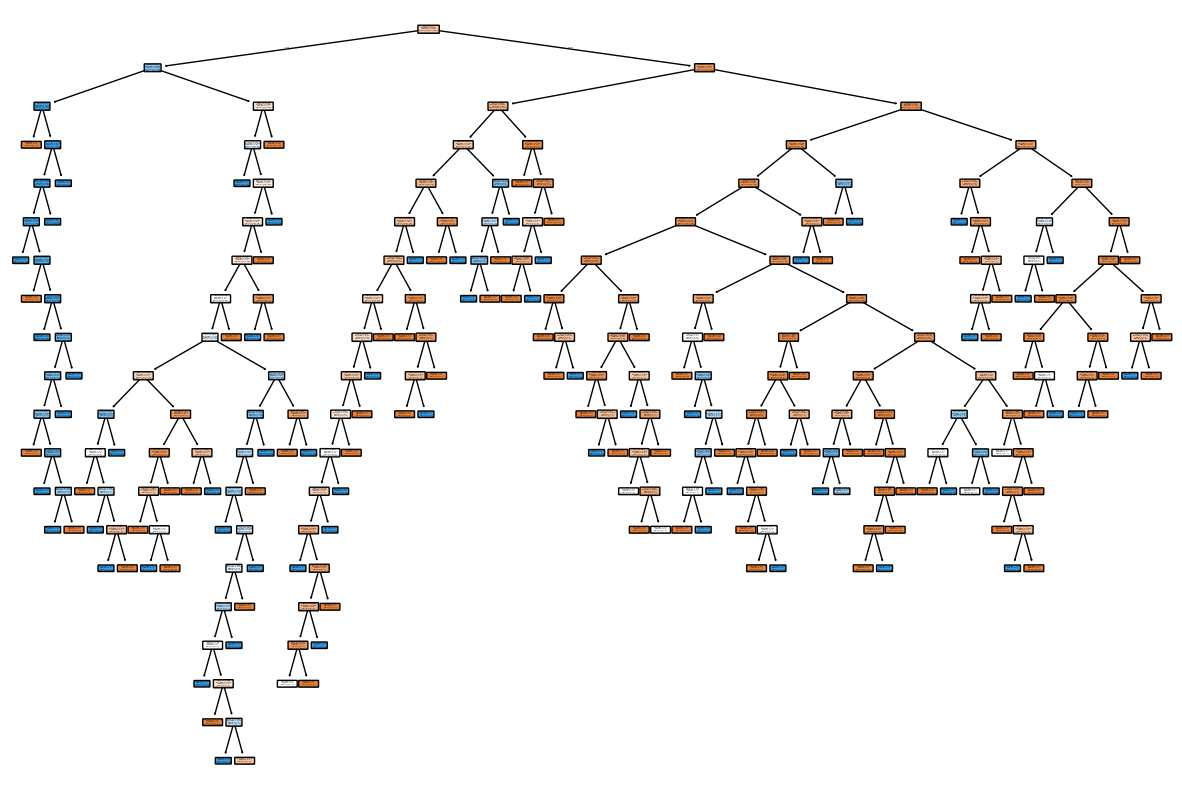

In [21]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
choose_tree=model.estimators_[50]
plt.figure(figsize=(15,10))
plot_tree(choose_tree,feature_names=['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare'],class_names=["Not Survived","Survived"],filled=True
          ,rounded=True)
plt.show()

In [22]:
df=pd.DataFrame({"Weight":[150,170,140,180,160,155],
               "Textare":["Smooth","Rough","Smooth","Rough","Smooth","Rough"],
               "Color":["Red","Orange","Green","Orange","Red","Yellow"],
                 "Fruit":["Apple","Orange","Apple","Orange","Apple","Orange"]})
df

,Weight,Textare,Color,Fruit
0,150,Smooth,Red,Apple
1,170,Rough,Orange,Orange
2,140,Smooth,Green,Apple
3,180,Rough,Orange,Orange
4,160,Smooth,Red,Apple
5,155,Rough,Yellow,Orange


In [23]:
import numpy as np
df["Textare"]=np.where(df["Textare"]=="Smooth",0,1)


In [24]:
df

,Weight,Textare,Color,Fruit
0,150,0,Red,Apple
1,170,1,Orange,Orange
2,140,0,Green,Apple
3,180,1,Orange,Orange
4,160,0,Red,Apple
5,155,1,Yellow,Orange


In [25]:
df["Color"]=np.where(df["Color"]=="Red",0,np.where(df["Color"]=="Orange",1,np.where(df["Color"]=="Green",2,3)))

In [26]:
df

,Weight,Textare,Color,Fruit
0,150,0,0,Apple
1,170,1,1,Orange
2,140,0,2,Apple
3,180,1,1,Orange
4,160,0,0,Apple
5,155,1,3,Orange


In [27]:
x=df[['Weight', 'Textare', 'Color']]
y=df["Fruit"]
print(x.shape)
print(y.shape)

(6, 3)
(6,)


In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4, 3)
(2, 3)
(4,)
(2,)


In [29]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(criterion="entropy",n_estimators=10,random_state=1)
model=rf.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

['Apple' 'Orange']


In [30]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
print()
print("Accuracy Score : ",accuracy_score(y_test,y_pred))

[[1 0]
 [0 1]]

Accuracy Score :  1.0


In [31]:
# Error Rate
print("Error Rate : ",((FN+FP)/(TP+TN+FN+FP)))

Error Rate :  0.2122905027932961


In [32]:
sample=x_test.iloc[0:1]
print(sample)
prediction=model.predict(sample)
print(prediction)

   Weight  Textare  Color
2     140        0      2
['Apple']


In [33]:
sample_dict=sample.iloc[0].to_dict()
print(f"Sample Passanger : {sample_dict}")
print(f"Predicted Survvived : {'Survived' if prediction[0]==1 else 'Not Survived'}")

Sample Passanger : {'Weight': 140, 'Textare': 0, 'Color': 2}
Predicted Survvived : Not Survived


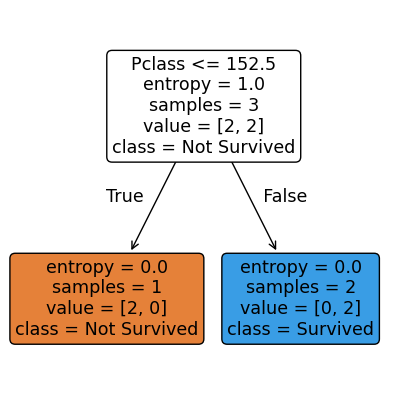

In [41]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
choose_tree=model.estimators_[5]
plt.figure(figsize=(5,5))
plot_tree(choose_tree,feature_names=['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare'],class_names=["Not Survived","Survived"],filled=True
          ,rounded=True)
plt.show()

In [3]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
x=df.iloc[:,0:8]
y=df.iloc[:,-1]
print(x.shape)
print(y.shape)


(768, 8)
(768,)


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [6]:
from sklearn.svm import SVC
classifier=SVC(kernel='rbf',C=1.0,random_state=0)
model=classifier.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]


In [7]:
from sklearn.metrics import accuracy_score,confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)
print("Accuracy Score : ",accuracy_score(y_test,prediction))

[[93  6]
 [27 28]]
Accuracy Score :  0.7857142857142857
